In [11]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Generating training dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

reviews_df = pd.read_csv("../data/interim/reviews_processed.csv")
sessions_df_clean = pd.read_csv("../data/interim/sessions_processed.csv")
listings_df = pd.read_csv("../data/interim/listings_processed.csv")

# Parse dates
reviews_df['date'] = pd.to_datetime(reviews_df['date'], errors='coerce')
reviews_df = reviews_df.dropna(subset=['date'])
sessions_df_clean['timestamp'] = pd.to_datetime(sessions_df_clean['timestamp'])

print(f"Reviews: {reviews_df.shape}")
print(f"Sessions: {sessions_df_clean.shape}")
print(f"Listings: {listings_df.shape}")

Reviews: (46935, 9)
Sessions: (470445, 4)
Listings: (3646, 8)


In [13]:
# Filter to relevant session types
sessions_filtered = sessions_df_clean[sessions_df_clean['action'].isin(['view_listing', 'book_listing'])].copy()
sessions_filtered = sessions_filtered.drop_duplicates()

# Separate views from bookings
views_df = sessions_filtered[sessions_filtered["action"] == "view_listing"][['user_id', 'timestamp', 'listing_id']].copy()
bookings_df = sessions_filtered[sessions_filtered["action"] == "book_listing"][['user_id', 'listing_id', 'timestamp']].copy()
bookings_df = bookings_df.rename(columns={'timestamp': 'booking_timestamp'})

# Forward point-in-time join: for each view, find if a booking happened within 24h
views_df = views_df.sort_values('timestamp')
bookings_df = bookings_df.sort_values('booking_timestamp')
merged_df = pd.merge_asof(
    left=views_df,
    right=bookings_df,
    left_on='timestamp',
    right_on='booking_timestamp',
    by=['user_id', 'listing_id'],
    direction='forward',
    tolerance=pd.Timedelta(hours=24)
)

# Y=1 if booking timestamp present (offer was reserved)
merged_df['Y'] = merged_df['booking_timestamp'].notna().astype(int)
training_data = merged_df.drop(columns=['booking_timestamp']).reset_index(drop=True)
print(f"Training data: {training_data.shape}")

Training data: (431281, 4)


In [14]:
print(len(training_data[training_data["Y"] == 1]))
print(len(training_data[training_data["Y"] == 0]))

15546
415735


## Feature engineering

For each training row (a user viewing a listing at time $T_0$), we compute review-based features looking **only at reviews posted before** $T_0$ (point-in-time correctness). Reviews become visible the day after posting (D+1 rule) to avoid data leakage.

**Generated features:**

| Feature | Description |
|---|---|
| `days_since_last_review` | Days between $T_0$ and the most recent visible review. -1 if listing has no reviews yet. |
| `reviews_in_last_90_days` | Count of reviews that became visible within 90 days before $T_0$. |
| `recent_review_scores_*` | Average VADER sentiment scores of reviews in the 90-day window (7 columns). |
| `alltime_review_count` | Total number of reviews visible at $T_0$. |
| `alltime_review_scores_*` | Average VADER sentiment scores across ALL visible reviews (7 columns). |

Then static listing attributes (price, bedrooms, etc.) are joined via **inner join** (only sessions with known listings are kept).

In [15]:
sentiment_cols = [c for c in reviews_df.columns if c.startswith('review_scores_')]

# D+1 rule: a review posted on day D becomes visible on day D+1
reviews_df['visible_date'] = reviews_df['date'] + pd.Timedelta(days=1)

# FEATURE: days_since_last_review
# merge_asof backward: find the latest review visible BEFORE each session
td_sorted = training_data[['listing_id', 'timestamp']].copy()
td_sorted['_orig_idx'] = td_sorted.index
td_sorted = td_sorted.sort_values('timestamp')

rv_for_asof = reviews_df[['listing_id', 'visible_date', 'date']].sort_values('visible_date')

asof_result = pd.merge_asof(
    td_sorted,
    rv_for_asof.rename(columns={'visible_date': '_vis_ts', 'date': '_review_date'}),
    left_on='timestamp',
    right_on='_vis_ts',
    by='listing_id',
    direction='backward'
)
asof_result['days_since_last_review'] = (asof_result['timestamp'] - asof_result['_review_date']).dt.days

# NaN = listing has no reviews at all → fill with -1
training_data['days_since_last_review'] = (
    asof_result.set_index('_orig_idx')['days_since_last_review'].fillna(-1).astype(int)
)

pct_no_review = (training_data['days_since_last_review'] == -1).mean() * 100
print(f"days_since_last_review: {pct_no_review:.1f}% have no reviews (filled with -1)")
print(training_data['days_since_last_review'].describe())

days_since_last_review: 73.0% have no reviews (filled with -1)
count    431281.000000
mean        158.668610
std         445.360041
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          21.000000
max        4271.000000
Name: days_since_last_review, dtype: float64


In [16]:
# FEATURES: 90-day window + all-time historical features
td_slim = training_data[['listing_id', 'timestamp']].copy()
td_slim['_td_idx'] = td_slim.index

rv_slim = reviews_df[['listing_id', 'visible_date'] + sentiment_cols].copy()

print("Joining training rows with reviews...")
merged = td_slim.merge(rv_slim, on='listing_id', how='inner')

# Keep only reviews visible BEFORE the session
merged = merged[merged['visible_date'] <= merged['timestamp']]
merged['days_ago'] = (merged['timestamp'] - merged['visible_date']).dt.days
print(f"Total visible review-session pairs: {len(merged):,}")

# --- ALL-TIME features ---
alltime_agg = {col: 'mean' for col in sentiment_cols}
alltime_agg['visible_date'] = 'count'
alltime = merged.groupby('_td_idx').agg(alltime_agg)
alltime = alltime.rename(columns={'visible_date': 'alltime_review_count'})
alltime = alltime.rename(columns={c: f'alltime_{c}' for c in sentiment_cols})

# --- 90-DAY WINDOW features ---
recent = merged[merged['days_ago'] <= 90]
recent_agg = {col: 'mean' for col in sentiment_cols}
recent_agg['visible_date'] = 'count'
recent_feats = recent.groupby('_td_idx').agg(recent_agg)
recent_feats = recent_feats.rename(columns={'visible_date': 'reviews_in_last_90_days'})
recent_feats = recent_feats.rename(columns={c: f'recent_{c}' for c in sentiment_cols})

# Join all features back
training_data = training_data.join(alltime)
training_data = training_data.join(recent_feats)

# Fill NaN (sessions with no reviews at all)
training_data['alltime_review_count'] = training_data['alltime_review_count'].fillna(0).astype(int)
training_data['reviews_in_last_90_days'] = training_data['reviews_in_last_90_days'].fillna(0).astype(int)
for c in sentiment_cols:
    training_data[f'alltime_{c}'] = training_data[f'alltime_{c}'].fillna(0.0)
    training_data[f'recent_{c}'] = training_data[f'recent_{c}'].fillna(0.0)

pct_90d = (training_data['reviews_in_last_90_days'] > 0).mean() * 100
pct_all = (training_data['alltime_review_count'] > 0).mean() * 100
print(f"\nCoverage: {pct_90d:.1f}% have reviews in 90-day window, {pct_all:.1f}% have any review ever")
print(f"Features computed. Shape: {training_data.shape}")
training_data.head()

Joining training rows with reviews...
Total visible review-session pairs: 504,007

Coverage: 6.3% have reviews in 90-day window, 27.0% have any review ever
Features computed. Shape: (431281, 21)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,alltime_review_scores_rating,alltime_review_count,recent_review_scores_cleanliness,recent_review_scores_location,recent_review_scores_communication,recent_review_scores_checkin,recent_review_scores_value,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [17]:
# Inner join: keep only sessions for listings we have data for
# (the listing table is a snapshot — old/removed listings are missing)
rows_before = len(training_data)
training_data['listing_id'] = training_data['listing_id'].astype('Int64')
listings_df['listing_id'] = listings_df['listing_id'].astype('Int64')
training_data = training_data.merge(listings_df, on='listing_id', how='inner')
print(f"Rows before join: {rows_before:,} → after inner join: {len(training_data):,} ({100*len(training_data)/rows_before:.1f}% kept)")

# Impute remaining nulls in numeric listing columns with median
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'price']
for col in num_cols:
    n_null = training_data[col].isnull().sum()
    if n_null > 0:
        training_data[col] = training_data[col].fillna(training_data[col].median())
        print(f"Imputed {n_null} nulls in {col} with median")

# Fill null categoricals with "Unknown"
# Encoding is deferred to the modeling notebook (OneHotEncoder fit on training split only)
cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed']
for col in cat_cols:
    training_data[col] = training_data[col].fillna('Unknown')

print(f"\nFinal training data: {training_data.shape}")
print(f"Nulls remaining: {training_data.isnull().sum().sum()}")
print("\nCategorical cardinalities:")
for col in cat_cols:
    print(f"  {col}: {training_data[col].nunique()} unique values")
training_data.head()

Rows before join: 431,281 → after inner join: 317,277 (73.6% kept)
Imputed 61553 nulls in accommodates with median
Imputed 66307 nulls in bathrooms with median
Imputed 73392 nulls in bedrooms with median
Imputed 164782 nulls in price with median

Final training data: (317277, 28)
Nulls remaining: 0

Categorical cardinalities:
  property_type: 8 unique values
  room_type: 5 unique values
  neighbourhood_cleansed: 12 unique values


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,812.0,Bispebjerg
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,3.0,1359.0,Vesterbro-Kongens Enghave
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,1.0,1200.0,Indre By
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,5.0,1.0,3.0,2821.0,Unknown
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,629.0,Vesterbro-Kongens Enghave


## Class distribution

Class 0 (no booking): 314,973
Class 1 (booking):    2,304
Imbalance ratio Y=1/Y=0: 0.0073


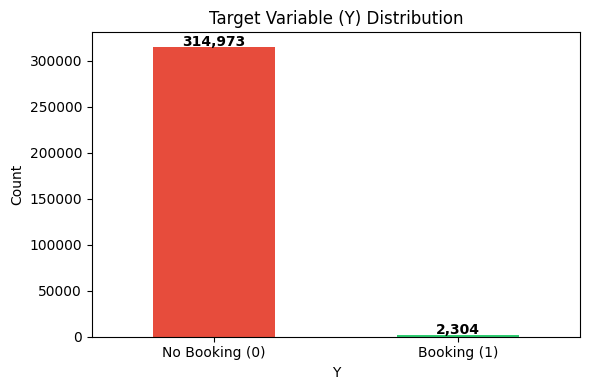

In [18]:
counts = training_data['Y'].value_counts().sort_index()
print(f"Class 0 (no booking): {counts.get(0, 0):,}")
print(f"Class 1 (booking):    {counts.get(1, 0):,}")
print(f"Imbalance ratio Y=1/Y=0: {counts.get(1, 0) / counts.get(0, 1):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['No Booking (0)', 'Booking (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Variable (Y) Distribution')
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Generating inference sample

In [19]:
# Generate inference sample from the most recent 30 days of data
latest_date = training_data['timestamp'].max()
cutoff = latest_date - pd.Timedelta(days=30)

inference_sample = training_data[training_data['timestamp'] >= cutoff].copy()
inference_sample = inference_sample.drop(columns=['Y'])  # Target not available at inference time

print(f"Inference sample: {inference_sample.shape} (last 30 days of data)")
inference_sample.head()

Inference sample: (508, 27) (last 30 days of data)


,user_id,timestamp,listing_id,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,alltime_review_scores_accuracy,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
316769,40137464,2025-08-09 20:35:12.006548,955594135974379648,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Unknown,Unknown,2.0,1.0,1.0,1200.0,Vesterbro-Kongens Enghave
316770,360554333,2025-08-09 21:05:24.508420,1244147958257977344,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Unknown,Entire home/apt,2.0,1.0,1.0,1035.0,sterbro
316771,179697571,2025-08-09 21:25:27.516388,1397753249851294464,5,0.0,0.6324,0.3592,0.0,0.0,0.32945,...,0.32945,0.9373,2,Private room in condo,Private room,1.0,1.0,1.0,1200.0,Nrrebro
316772,360554333,2025-08-09 21:46:06.508420,1502922937698947584,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,2143.0,Unknown
316773,179697571,2025-08-09 22:20:52.516388,1434115704779021312,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Entire rental unit,Entire home/apt,3.0,2.0,1.0,2050.0,Unknown


In [20]:
import os
os.makedirs("../data/processed", exist_ok=True)

training_data.to_csv("../data/processed/training_data.csv", index=False)
inference_sample.to_csv("../data/processed/inference_sample.csv", index=False)
print(f"Saved training_data.csv ({training_data.shape}) and inference_sample.csv ({inference_sample.shape}) to data/processed/")

Saved training_data.csv ((317277, 28)) and inference_sample.csv ((508, 27)) to data/processed/
